# Extra Practice

This is meant to help you practise the same core skills you developed in the previous exercises. Completing these exercises are **optional** and only meant to provide a little extra practice if you want. 


### Set up Python Libraries

As usual you will need to run this code block to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 1. Does a New Year mean more exercise?

A researcher investigates whether making a New Year’s resolution leads to an increase in exercise behaviour.

Participants report the average number of minutes they spend exercising per week at two time points:

- **December**, before the New Year
- **January**, after the New Year

Exercise time is measured in minutes per week, with higher values indicating more exercise.


a) Load the data into a Pandas dataframe

In [2]:
resolution = pd.read_csv("https://raw.githubusercontent.com/SageBoettcher/StatsCourseBook_2026/main/data/new_years_resolution.csv")

resolution

,ParticipantID,Resolution,ExerciseMinutes_December,ExerciseMinutes_January
0,1,No,148.7,121.4
1,2,Yes,159.3,182.9
2,3,Yes,110.8,139.8
3,4,No,104.9,99.2
4,5,Yes,101.6,140.1
5,6,Yes,64.4,97.0
6,7,No,68.6,71.8
7,8,Yes,187.9,220.8
8,9,Yes,66.7,56.2
9,10,No,130.6,163.2


b) Plot the raw data for December and January exercise time, and plot the distribution of the paired differences. Comment on both plots.

You may find it helpful to add a `Diff` column to the dataset

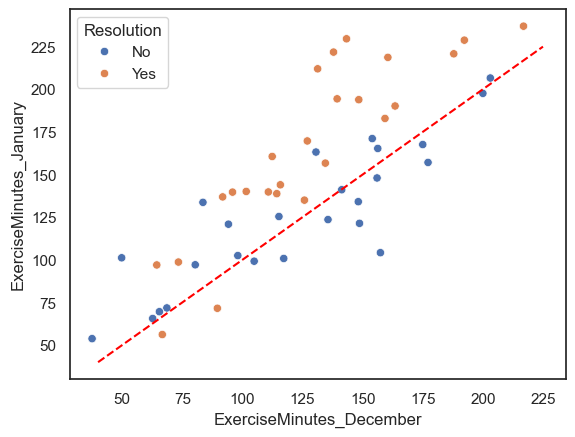

In [3]:
sns.scatterplot(data=resolution, x='ExerciseMinutes_December', y='ExerciseMinutes_January', hue='Resolution')
plt.plot([40,225],[40,225], color='red', linestyle='--')

In [4]:
resolution['Difference'] = resolution.ExerciseMinutes_January - resolution.ExerciseMinutes_December

<Axes: xlabel='Difference', ylabel='Density'>

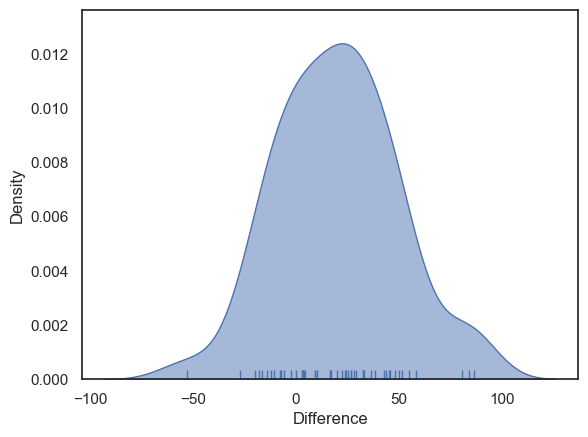

In [5]:
sns.kdeplot(data=resolution, x='Difference', fill=True, alpha=0.5)
sns.rugplot(data=resolution, x='Difference')

c) Conduct a suitable $t$-test to assess whether exercise increases after the New Year. For this you should:

- State the null and alternative hypotheses.
- Report relevant descriptive statistics
- Carry out an appropriate **$t$-test** using the built-in function from `scipy.stats`,
- State your conclusion in words


In [6]:
resolution.describe()

,ParticipantID,ExerciseMinutes_December,ExerciseMinutes_January,Difference
count,50.00000,50.000000,50.000000,50.000000
mean,25.50000,125.316000,145.148000,19.832000
std,14.57738,42.479168,49.447388,28.997667
min,1.00000,37.500000,53.800000,-53.200000
25%,13.25000,94.625000,102.925000,0.575000
50%,25.50000,128.800000,139.950000,21.150000
75%,37.75000,155.500000,179.950000,38.000000
max,50.00000,216.900000,237.000000,86.300000


In [7]:
stats.ttest_rel(resolution.ExerciseMinutes_January, resolution.ExerciseMinutes_December, alternative='greater')


TtestResult(statistic=np.float64(4.8360241768420575), pvalue=np.float64(6.771516782100402e-06), df=np.int64(49))

## 2. Did it matter whether a person made a resolution?

The researcher also wanted to determine whether the increase in exercise after the New Year depended on whether a participant had made a New Year’s resolution.

In particular, they asked whether people who made a resolution to exercise more showed a greater increase in weekly exercise time than those who did not. This question compares **independent groups** and can be addressed by comparing exercise behaviour (or the change in exercise) between the two groups.

a) Plot the data and comment on what an appropriate test would be then carry out this test


<Axes: xlabel='Difference', ylabel='Density'>

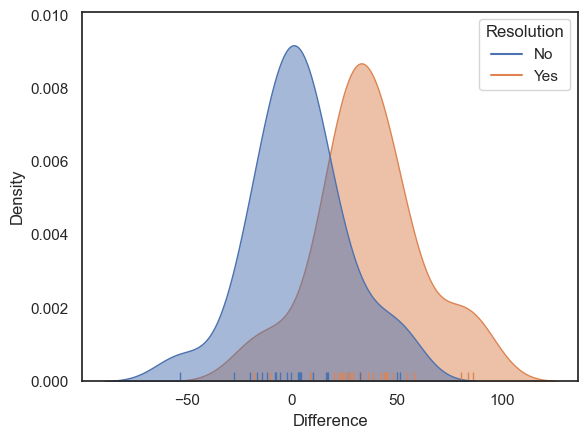

In [8]:
sns.kdeplot(data=resolution, x='Difference', hue='Resolution', fill=True, alpha=0.5)
sns.rugplot(data=resolution, x='Difference', hue='Resolution')

b) Conduct a suitable $t$-test to assess whether people who made a resolution showed a greater increase after the New Year. For this you should:

- State the null and alternative hypotheses.
- Report relevant descriptive statistics.
- Carry out an appropriate **$t$-test** using the built-in function from `scipy.stats`, with suitable option choices.
- State your conclusion in words.


In [9]:
resolution.groupby('Resolution').Difference.describe()

,count,mean,std,min,25%,50%,75%,max
Resolution,,,,,,,,
No,25.0,3.256,22.821811,-53.2,-8.0,3.2,16.3,51.4
Yes,25.0,36.408,24.970097,-18.0,24.5,32.9,45.5,86.3


In [10]:
stats.ttest_ind(resolution.query('Resolution=="Yes"').Difference, 
                resolution.query('Resolution=="No"').Difference, alternative='greater')

TtestResult(statistic=np.float64(4.900067250772657), pvalue=np.float64(5.660317553864346e-06), df=np.float64(48.0))

## 3. Is baseline exercise different from the recommended level?

Finally, the researcher wanted to know whether participants’ baseline exercise levels differed from a commonly recommended guideline.

In particular, they asked whether the average amount of exercise reported in December differed from the recommended level of 150 minutes of exercise per week. This question compares a **single sample mean** to a known reference value and can be addressed using a **one-sample $t$-test**.

a) Plot the data and comment on what an appropriate test would be then carry out this test

<Axes: xlabel='ExerciseMinutes_December', ylabel='Density'>

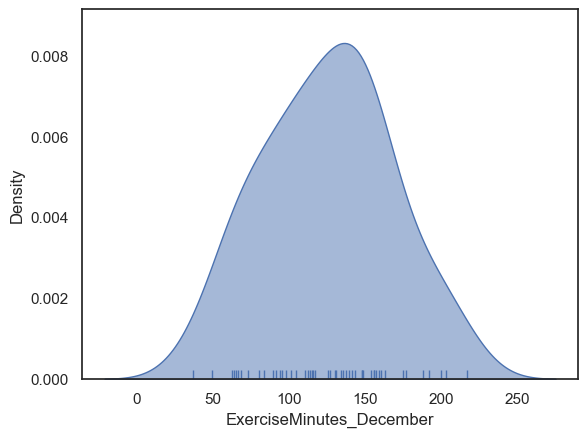

In [11]:
sns.kdeplot(data=resolution, x = 'ExerciseMinutes_December', fill=True, alpha=0.5)
sns.rugplot(data=resolution, x = 'ExerciseMinutes_December')



b) Conduct a suitable $t$-test to assess whether the baseline differed from the recommended 150mins:

- State the null and alternative hypotheses.
- Report relevant descriptive statistics.
- Carry out an appropriate **$t$-test** using the built-in function from `scipy.stats`, with suitable option choices.
- State your conclusion in words.


In [12]:
resolution.ExerciseMinutes_December.describe()

count     50.000000
mean     125.316000
std       42.479168
min       37.500000
25%       94.625000
50%      128.800000
75%      155.500000
max      216.900000
Name: ExerciseMinutes_December, dtype: float64

In [13]:
stats.ttest_1samp(resolution.ExerciseMinutes_December, 150, alternative='two-sided')


TtestResult(statistic=np.float64(-4.108890189857565), pvalue=np.float64(0.0001507103809970735), df=np.int64(49))